# Evaluating Vision-Language Models on Controlled Spatial Reasoning

This notebook implements a compact, reproducible Vision-Language Model evaluation pipeline from scratch.

It focuses on tasks relevant to Spatial AI:

- direct spatial relations;
- distractor-based reasoning;
- compositional reasoning;
- multi-image reasoning;
- language-based localization.

The scenes are generated procedurally, so the ground truth is exact.

The primary model is:

`HuggingFaceTB/SmolVLM2-2.2B-Instruct`

An optional Qwen2.5-VL extension is included at the end, but the core project is complete with SmolVLM2 alone.

## 0. Colab setup

Recommended runtime:

`Runtime → Change runtime type → T4 GPU`

The setup below removes `hf_xet`, which can cause stalled large-file downloads in some Colab sessions, and installs the missing `num2words` dependency used by the processor.

After running this cell, restart the runtime once.

In [1]:
!pip uninstall -y hf_xet -q
!pip install -q num2words

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 7.9 MB/s eta 0:00:00


### Restart required

After running the previous cell:

`Runtime → Restart session`

Then continue from the next cell.

Do not rerun the uninstall/install cell unless you create a fresh runtime.

## 1. Imports and environment check

In [1]:
from __future__ import annotations

import gc
import json
import math
import random
import re
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageDraw
from tqdm.auto import tqdm

import transformers
import huggingface_hub

from huggingface_hub import notebook_login, snapshot_download
from transformers import AutoModelForImageTextToText, AutoProcessor

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FLOAT_DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch: 2.11.0+cu128
transformers: 5.12.1
huggingface_hub: 1.20.1
CUDA available: True
GPU: Tesla T4


## 2. Hugging Face authentication

Use a read-only Hugging Face token.

Do not paste a token directly into notebook code, especially if the notebook will be published on GitHub.

In [3]:
notebook_login()

## 3. Robust model download

`snapshot_download` stores completed files in the Hugging Face cache.

If a temporary HTTP or CDN error occurs, rerun this cell without deleting the cache. Already completed files will be reused.

In [8]:
MODEL_ID = "HuggingFaceTB/SmolVLM2-2.2B-Instruct"

model_path = snapshot_download(
    repo_id=MODEL_ID,
    allow_patterns=["*.safetensors", "*.json", "*.txt", "*.model"],
    max_workers=1,
)

print("Model downloaded to:", model_path)

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Model downloaded to: /root/.cache/huggingface/hub/models--HuggingFaceTB--SmolVLM2-2.2B-Instruct/snapshots/482adb537c021c86670beed01cd58990d01e72e4


## 4. Load processor and model

A modern VLM usually contains:

1. a vision encoder;
2. a connector or projection module;
3. a language model.

The processor prepares both text and images.  
The model combines the visual and textual representations and generates text autoregressively.

In [9]:
processor = AutoProcessor.from_pretrained(model_path)

model = AutoModelForImageTextToText.from_pretrained(
    model_path,
    dtype=FLOAT_DTYPE,
).to(DEVICE)

model.eval()

print("Loaded:", MODEL_ID)
print("Device:", next(model.parameters()).device)
print("Parameter dtype:", next(model.parameters()).dtype)

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

Loaded: HuggingFaceTB/SmolVLM2-2.2B-Instruct
Device: cuda:0
Parameter dtype: torch.bfloat16


## 5. Project folders

In [10]:
ROOT = Path("spatial_vlm_project")
IMAGES_DIR = ROOT / "images"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"

for directory in [IMAGES_DIR, RESULTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT.resolve())

Project root: /content/spatial_vlm_project


# Part I — Understanding the VLM inference pipeline

We begin with a controlled scene:

- a red circle on the left;
- a blue square on the right.

The expected answer is therefore `left`.

## 6. Generate a controlled scene

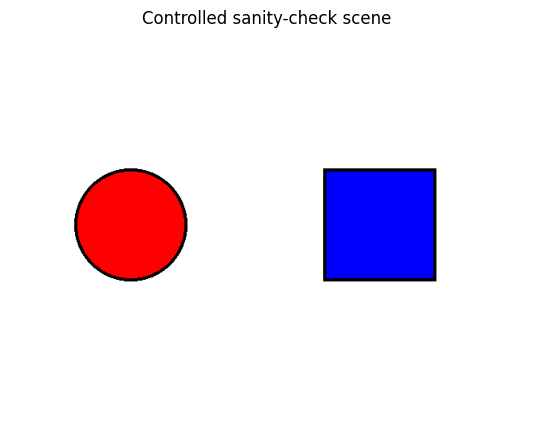

In [11]:
sanity_path = IMAGES_DIR / "sanity_red_circle_blue_square.png"

image = Image.new("RGB", (640, 480), "white")
draw = ImageDraw.Draw(image)

draw.ellipse(
    (80, 170, 220, 310),
    fill="red",
    outline="black",
    width=4,
)

draw.rectangle(
    (390, 170, 530, 310),
    fill="blue",
    outline="black",
    width=4,
)

image.save(sanity_path)

plt.figure(figsize=(7, 5))
plt.imshow(image)
plt.axis("off")
plt.title("Controlled sanity-check scene")
plt.show()

## 7. Build the multimodal message

The message contains:

- `role`: who is speaking;
- `content`: a list of modalities;
- an image placeholder;
- the textual question.

In [12]:
sanity_question = (
    "Where is the red circle relative to the blue square? "
    "Answer using only one lowercase word: left, right, above, or below."
)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": sanity_question},
        ],
    }
]

messages

[{'role': 'user',
  'content': [{'type': 'image'},
   {'type': 'text',
    'text': 'Where is the red circle relative to the blue square? Answer using only one lowercase word: left, right, above, or below.'}]}]

## 8. Apply the model-specific chat template

Different VLMs are trained with different conversation formats.

`apply_chat_template` converts the generic message structure into the exact prompt format expected by SmolVLM2.

In [13]:
formatted_prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
)

print(formatted_prompt)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


<|im_start|>User:<image>Where is the red circle relative to the blue square? Answer using only one lowercase word: left, right, above, or below.<end_of_utterance>
Assistant:


## 9. Process image and text

The processor:

- tokenizes text;
- creates `input_ids`;
- creates an `attention_mask`;
- resizes and normalizes the image;
- creates `pixel_values`;
- creates any model-specific visual metadata.

In [14]:
sanity_image = Image.open(sanity_path).convert("RGB")

model_inputs = processor(
    text=formatted_prompt,
    images=[sanity_image],
    return_tensors="pt",
)

print("Input keys:", model_inputs.keys())

for key, value in model_inputs.items():
    if hasattr(value, "shape"):
        print(
            f"{key:25s} "
            f"shape={tuple(value.shape)}, "
            f"dtype={value.dtype}"
        )

Input keys: KeysView({'pixel_values': tensor([[[[[1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           ...,
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.]],

          [[1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           ...,
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.]],

          [[1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           ...,
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.]]],


         [[[1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
   

## 10. Move tensors to the correct device

Floating-point tensors such as image pixels are converted to `bfloat16` on GPU.

Integer tensors such as token IDs remain integer-valued.

In [15]:
def move_inputs_to_device(
    inputs: dict[str, torch.Tensor],
    device: str,
    float_dtype: torch.dtype,
) -> dict[str, torch.Tensor]:
    moved = {}

    for key, value in inputs.items():
        if value.is_floating_point():
            moved[key] = value.to(device, dtype=float_dtype)
        else:
            moved[key] = value.to(device)

    return moved


model_inputs = move_inputs_to_device(
    model_inputs,
    device=DEVICE,
    float_dtype=FLOAT_DTYPE,
)

for key, value in model_inputs.items():
    if hasattr(value, "shape"):
        print(
            f"{key:25s} "
            f"device={value.device}, "
            f"dtype={value.dtype}"
        )

pixel_values              device=cuda:0, dtype=torch.bfloat16
pixel_attention_mask      device=cuda:0, dtype=torch.int64
input_ids                 device=cuda:0, dtype=torch.int64
attention_mask            device=cuda:0, dtype=torch.int64


## 11. Generate the answer

`model.generate()` predicts output tokens autoregressively.

`do_sample=False` makes inference deterministic, which is preferable for evaluation.

In [16]:
with torch.inference_mode():
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=20,
        do_sample=False,
    )

print("Generated IDs shape:", generated_ids.shape)

Generated IDs shape: torch.Size([1, 1120])


## 12. Decode only the generated answer

The generated sequence contains both the original prompt and the newly generated tokens.

We remove the input tokens before decoding.

In [17]:
input_length = model_inputs["input_ids"].shape[1]
generated_only = generated_ids[:, input_length:]

raw_answer = processor.batch_decode(
    generated_only,
    skip_special_tokens=True,
)[0].strip()

print("Raw prediction:", raw_answer)
print("Expected answer: left")

Raw prediction: left
Expected answer: left


## 13. Reusable inference adapter

The function below packages the entire pipeline into one reusable interface.

This is important because later another VLM can implement the same conceptual interface.

In [18]:
def ask_smolvlm(
    image_paths: list[str | Path],
    question: str,
    max_new_tokens: int = 40,
) -> str:
    if not image_paths:
        raise ValueError("At least one image is required.")

    images = []

    for image_path in image_paths:
        path = Path(image_path)

        if not path.exists():
            raise FileNotFoundError(f"Image not found: {path}")

        images.append(Image.open(path).convert("RGB"))

    content = [{"type": "image"} for _ in images]
    content.append({"type": "text", "text": question})

    messages = [
        {
            "role": "user",
            "content": content,
        }
    ]

    text = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
    )

    inputs = processor(
        text=text,
        images=images,
        return_tensors="pt",
    )

    inputs = move_inputs_to_device(
        inputs,
        device=DEVICE,
        float_dtype=FLOAT_DTYPE,
    )

    input_length = inputs["input_ids"].shape[1]

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    output_ids = output_ids[:, input_length:]

    answer = processor.batch_decode(
        output_ids,
        skip_special_tokens=True,
    )[0]

    return answer.strip()

In [19]:
prediction = ask_smolvlm(
    image_paths=[sanity_path],
    question=sanity_question,
    max_new_tokens=10,
)

print("Prediction:", prediction)
print("Expected:", "left")

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


Prediction: left
Expected: left


# Part II — Procedural spatial benchmark

The benchmark uses synthetic scenes because they provide exact ground truth.

The model sees only the rendered image and the textual question.

## 14. Scene generation utilities

In [20]:
COLORS = ["red", "blue", "green", "orange", "purple"]
SHAPES = ["circle", "square", "triangle"]

IMAGE_WIDTH = 640
IMAGE_HEIGHT = 480


def draw_shape(
    draw: ImageDraw.ImageDraw,
    shape: str,
    bbox: tuple[int, int, int, int],
    color: str,
) -> None:
    if shape == "circle":
        draw.ellipse(
            bbox,
            fill=color,
            outline="black",
            width=4,
        )

    elif shape == "square":
        draw.rectangle(
            bbox,
            fill=color,
            outline="black",
            width=4,
        )

    elif shape == "triangle":
        x1, y1, x2, y2 = bbox

        points = [
            ((x1 + x2) // 2, y1),
            (x1, y2),
            (x2, y2),
        ]

        draw.polygon(
            points,
            fill=color,
            outline="black",
        )

    else:
        raise ValueError(f"Unsupported shape: {shape}")


def make_bbox(
    center_x: int,
    center_y: int,
    size: int,
) -> tuple[int, int, int, int]:
    half = size // 2

    return (
        center_x - half,
        center_y - half,
        center_x + half,
        center_y + half,
    )

## 15. Direct spatial relation dataset

In [21]:
DIRECT_DIR = IMAGES_DIR / "direct_relations"
DIRECT_DIR.mkdir(exist_ok=True)

RELATION_POSITIONS = {
    "left": ((160, 240), (480, 240)),
    "right": ((480, 240), (160, 240)),
    "above": ((320, 130), (320, 350)),
    "below": ((320, 350), (320, 130)),
}


def create_direct_relation_sample(
    sample_id: int,
    relation: str,
) -> dict[str, Any]:
    image = Image.new(
        "RGB",
        (IMAGE_WIDTH, IMAGE_HEIGHT),
        "white",
    )
    draw = ImageDraw.Draw(image)

    color_a, color_b = random.sample(COLORS, 2)
    shape_a, shape_b = random.sample(SHAPES, 2)

    position_a, position_b = RELATION_POSITIONS[relation]

    jitter_a = (
        random.randint(-15, 15),
        random.randint(-15, 15),
    )
    jitter_b = (
        random.randint(-15, 15),
        random.randint(-15, 15),
    )

    center_a = (
        position_a[0] + jitter_a[0],
        position_a[1] + jitter_a[1],
    )
    center_b = (
        position_b[0] + jitter_b[0],
        position_b[1] + jitter_b[1],
    )

    bbox_a = make_bbox(*center_a, size=110)
    bbox_b = make_bbox(*center_b, size=110)

    draw_shape(draw, shape_a, bbox_a, color_a)
    draw_shape(draw, shape_b, bbox_b, color_b)

    image_path = DIRECT_DIR / f"direct_{sample_id:03d}.png"
    image.save(image_path)

    return {
        "id": f"direct_{sample_id:03d}",
        "task": "direct_relation",
        "image_paths": [str(image_path)],
        "question": (
            f"Where is the {color_a} {shape_a} relative to "
            f"the {color_b} {shape_b}? "
            "Answer using only one lowercase word: "
            "left, right, above, or below."
        ),
        "answer": relation,
        "metadata": {
            "target": f"{color_a} {shape_a}",
            "reference": f"{color_b} {shape_b}",
        },
    }


random.seed(SEED)

direct_relations = ["left", "right", "above", "below"] * 6

direct_dataset = [
    create_direct_relation_sample(index, relation)
    for index, relation in enumerate(direct_relations)
]

print("Direct-relation samples:", len(direct_dataset))

Direct-relation samples: 24


## 16. Visualize direct-relation samples

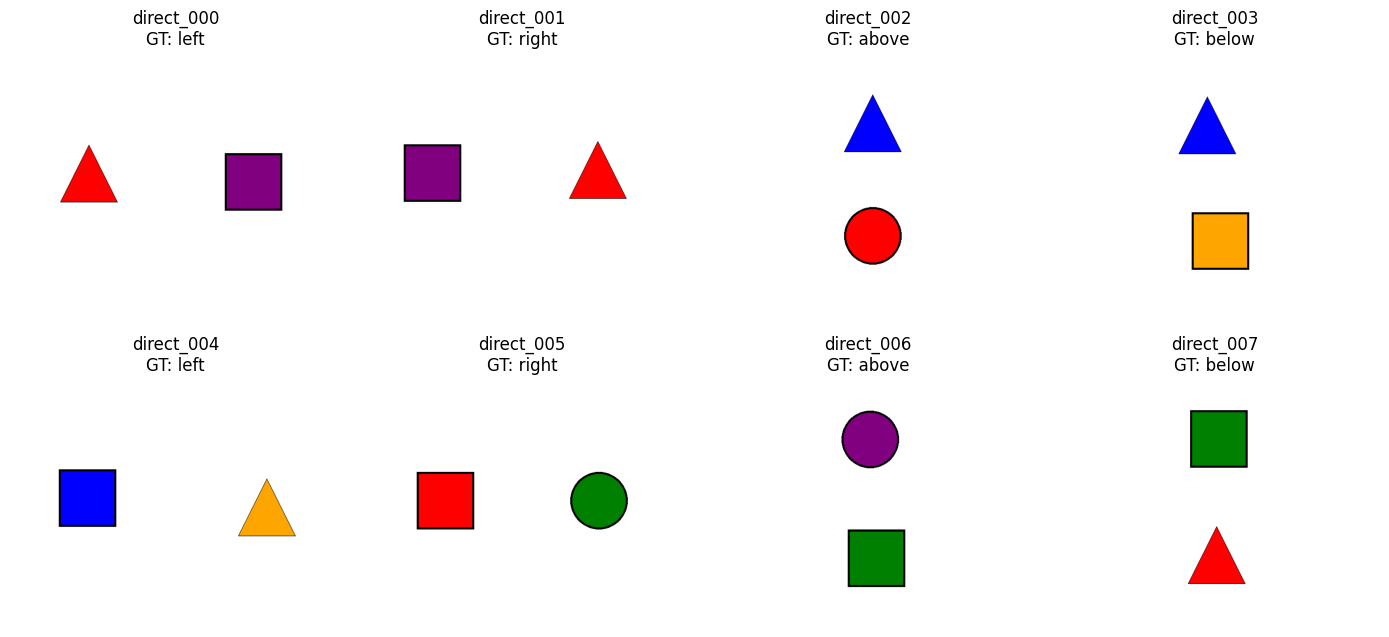

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for axis, sample in zip(axes.flat, direct_dataset[:8]):
    axis.imshow(Image.open(sample["image_paths"][0]))
    axis.set_title(
        f'{sample["id"]}\nGT: {sample["answer"]}'
    )
    axis.axis("off")

plt.tight_layout()
plt.show()

## 17. Normalize generated answers

In [23]:
VALID_RELATIONS = ["left", "right", "above", "below"]


def normalize_relation_answer(answer: str) -> str:
    text = answer.lower().strip()

    phrase_map = {
        "to the left": "left",
        "left of": "left",
        "on the left": "left",
        "to the right": "right",
        "right of": "right",
        "on the right": "right",
        "on top of": "above",
        "over": "above",
        "under": "below",
        "beneath": "below",
    }

    for phrase, canonical in phrase_map.items():
        if phrase in text:
            return canonical

    cleaned = re.sub(r"[^a-z\s]", " ", text)
    tokens = cleaned.split()

    for relation in VALID_RELATIONS:
        if relation in tokens:
            return relation

    return cleaned.strip()

## 18. Evaluate the direct-relation benchmark

In [24]:
def evaluate_dataset(
    samples: list[dict[str, Any]],
    max_new_tokens: int = 12,
) -> pd.DataFrame:
    rows = []

    for sample in tqdm(samples):
        try:
            raw_prediction = ask_smolvlm(
                image_paths=sample["image_paths"],
                question=sample["question"],
                max_new_tokens=max_new_tokens,
            )

            prediction = normalize_relation_answer(
                raw_prediction
            )

            error = None

        except Exception as exception:
            raw_prediction = ""
            prediction = ""
            error = repr(exception)

        rows.append(
            {
                "id": sample["id"],
                "task": sample["task"],
                "image_paths": sample["image_paths"],
                "question": sample["question"],
                "ground_truth": sample["answer"],
                "raw_prediction": raw_prediction,
                "prediction": prediction,
                "correct": prediction == sample["answer"],
                "error": error,
            }
        )

    return pd.DataFrame(rows)


direct_results = evaluate_dataset(direct_dataset)

display(direct_results.head())

  0%|          | 0/24 [00:00<?, ?it/s]

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transform

,id,task,image_paths,question,ground_truth,raw_prediction,prediction,correct,error
0,direct_000,direct_relation,[spatial_vlm_project/images/direct_relations/d...,Where is the red triangle relative to the purp...,left,left,left,True,None
1,direct_001,direct_relation,[spatial_vlm_project/images/direct_relations/d...,Where is the red triangle relative to the purp...,right,right,right,True,None
2,direct_002,direct_relation,[spatial_vlm_project/images/direct_relations/d...,Where is the blue triangle relative to the red...,above,above,above,True,None
3,direct_003,direct_relation,[spatial_vlm_project/images/direct_relations/d...,Where is the orange square relative to the blu...,below,below,below,True,None
4,direct_004,direct_relation,[spatial_vlm_project/images/direct_relations/d...,Where is the blue square relative to the orang...,left,left,left,True,None


## 19. Quantitative direct-relation results

In [25]:
overall_direct_accuracy = direct_results["correct"].mean()

direct_by_relation = (
    direct_results
    .groupby("ground_truth")["correct"]
    .agg(["mean", "count"])
    .reset_index()
)

direct_by_relation["accuracy_percent"] = (
    direct_by_relation["mean"] * 100
)

print(
    f"Overall direct-relation accuracy: "
    f"{overall_direct_accuracy:.2%}"
)

display(
    direct_by_relation[
        [
            "ground_truth",
            "accuracy_percent",
            "count",
        ]
    ]
)

Overall direct-relation accuracy: 83.33%


,ground_truth,accuracy_percent,count
0,above,100.000000,6
1,below,100.000000,6
2,left,100.000000,6
3,right,33.333333,6


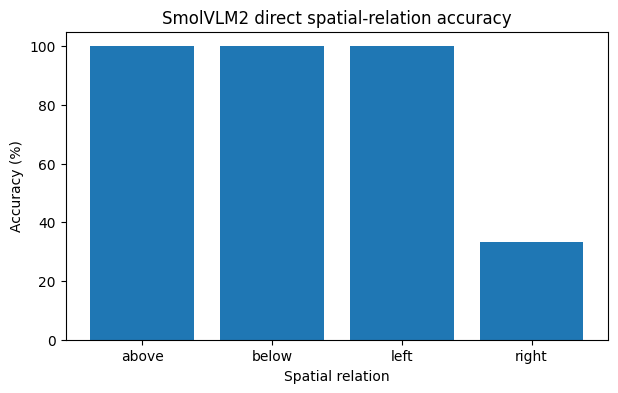

In [26]:
plt.figure(figsize=(7, 4))

plt.bar(
    direct_by_relation["ground_truth"],
    direct_by_relation["accuracy_percent"],
)

plt.ylim(0, 105)
plt.xlabel("Spatial relation")
plt.ylabel("Accuracy (%)")
plt.title("SmolVLM2 direct spatial-relation accuracy")
plt.show()

# Part III — Distractor-based reasoning

The next scenes contain additional objects.

The model must identify the correct target and reference objects before determining the spatial relation.

## 20. Generate distractor scenes

In [27]:
DISTRACTOR_DIR = IMAGES_DIR / "distractors"
DISTRACTOR_DIR.mkdir(exist_ok=True)


def create_distractor_sample(
    sample_id: int,
    relation: str,
) -> dict[str, Any]:
    image = Image.new(
        "RGB",
        (IMAGE_WIDTH, IMAGE_HEIGHT),
        "white",
    )
    draw = ImageDraw.Draw(image)

    color_a, color_b = random.sample(COLORS, 2)
    shape_a, shape_b = random.sample(SHAPES, 2)

    position_a, position_b = RELATION_POSITIONS[relation]

    bbox_a = make_bbox(*position_a, size=95)
    bbox_b = make_bbox(*position_b, size=95)

    draw_shape(draw, shape_a, bbox_a, color_a)
    draw_shape(draw, shape_b, bbox_b, color_b)

    used_descriptions = {
        f"{color_a} {shape_a}",
        f"{color_b} {shape_b}",
    }

    distractor_centers = [
        (120, 100),
        (520, 100),
        (120, 380),
        (520, 380),
    ]

    random.shuffle(distractor_centers)

    for center in distractor_centers[:3]:
        for _ in range(20):
            color = random.choice(COLORS)
            shape = random.choice(SHAPES)
            description = f"{color} {shape}"

            if description not in used_descriptions:
                used_descriptions.add(description)
                break

        draw_shape(
            draw,
            shape,
            make_bbox(*center, size=65),
            color,
        )

    image_path = DISTRACTOR_DIR / f"distractor_{sample_id:03d}.png"
    image.save(image_path)

    return {
        "id": f"distractor_{sample_id:03d}",
        "task": "distractor_relation",
        "image_paths": [str(image_path)],
        "question": (
            f"Ignore all unrelated objects. "
            f"Where is the {color_a} {shape_a} relative to "
            f"the {color_b} {shape_b}? "
            "Answer using only one lowercase word: "
            "left, right, above, or below."
        ),
        "answer": relation,
    }


random.seed(SEED + 1)

distractor_relations = ["left", "right", "above", "below"] * 4

distractor_dataset = [
    create_distractor_sample(index, relation)
    for index, relation in enumerate(distractor_relations)
]

print("Distractor samples:", len(distractor_dataset))

Distractor samples: 16


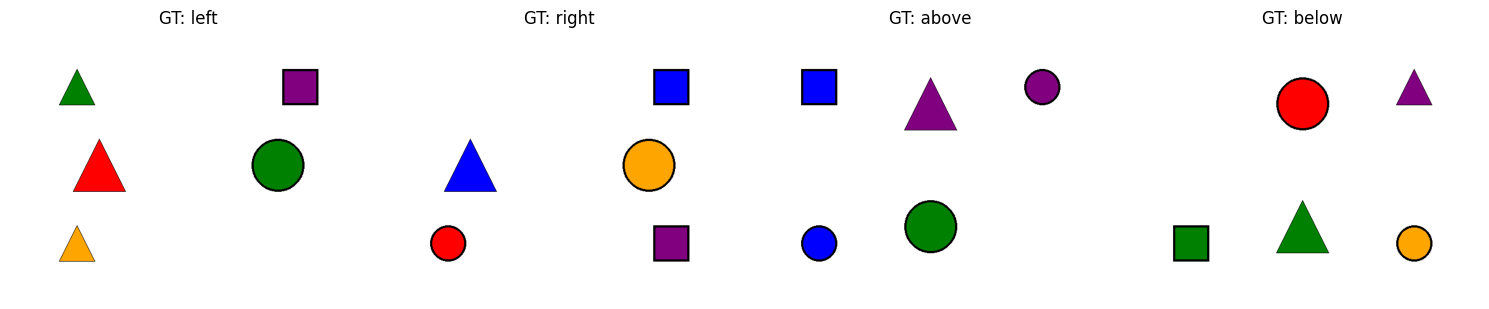

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for axis, sample in zip(axes, distractor_dataset[:4]):
    axis.imshow(Image.open(sample["image_paths"][0]))
    axis.set_title(f'GT: {sample["answer"]}')
    axis.axis("off")

plt.tight_layout()
plt.show()

## 21. Evaluate distractor scenes

In [29]:
distractor_results = evaluate_dataset(
    distractor_dataset
)

distractor_accuracy = (
    distractor_results["correct"].mean()
)

print(
    f"Distractor accuracy: "
    f"{distractor_accuracy:.2%}"
)

display(distractor_results.head())

  0%|          | 0/16 [00:00<?, ?it/s]

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transform

Distractor accuracy: 37.50%


,id,task,image_paths,question,ground_truth,raw_prediction,prediction,correct,error
0,distractor_000,distractor_relation,[spatial_vlm_project/images/distractors/distra...,Ignore all unrelated objects. Where is the red...,left,left,left,True,None
1,distractor_001,distractor_relation,[spatial_vlm_project/images/distractors/distra...,Ignore all unrelated objects. Where is the ora...,right,right,right,True,None
2,distractor_002,distractor_relation,[spatial_vlm_project/images/distractors/distra...,Ignore all unrelated objects. Where is the pur...,above,left,left,False,None
3,distractor_003,distractor_relation,[spatial_vlm_project/images/distractors/distra...,Ignore all unrelated objects. Where is the gre...,below,left,left,False,None
4,distractor_004,distractor_relation,[spatial_vlm_project/images/distractors/distra...,Ignore all unrelated objects. Where is the blu...,left,left,left,True,None


# Part IV — Multi-image reasoning

We now provide two images in the same prompt.

This verifies that the model can process multiple visual observations jointly.

## 22. Create a two-view example

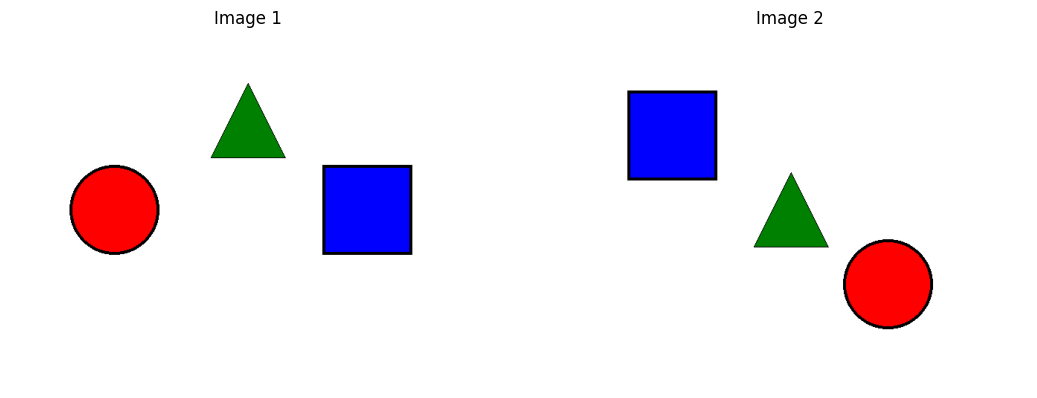

In [30]:
MULTIVIEW_DIR = IMAGES_DIR / "multiview"
MULTIVIEW_DIR.mkdir(exist_ok=True)

view_1_path = MULTIVIEW_DIR / "view_1.png"
view_2_path = MULTIVIEW_DIR / "view_2.png"

view_1 = Image.new("RGB", (640, 480), "white")
draw_1 = ImageDraw.Draw(view_1)

draw_1.ellipse(
    (80, 180, 200, 300),
    fill="red",
    outline="black",
    width=4,
)
draw_1.rectangle(
    (420, 180, 540, 300),
    fill="blue",
    outline="black",
    width=4,
)
draw_shape(
    draw_1,
    "triangle",
    (270, 70, 370, 170),
    "green",
)

view_2 = Image.new("RGB", (640, 480), "white")
draw_2 = ImageDraw.Draw(view_2)

draw_2.rectangle(
    (100, 80, 220, 200),
    fill="blue",
    outline="black",
    width=4,
)
draw_2.ellipse(
    (390, 280, 510, 400),
    fill="red",
    outline="black",
    width=4,
)
draw_shape(
    draw_2,
    "triangle",
    (270, 190, 370, 290),
    "green",
)

view_1.save(view_1_path)
view_2.save(view_2_path)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].imshow(view_1)
axes[0].set_title("Image 1")
axes[0].axis("off")

axes[1].imshow(view_2)
axes[1].set_title("Image 2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 23. Multi-image inference

In [33]:
multi_image_question = (
    "Consider Image 1 and Image 2. "
    "Do both images contain the same set of colored shape categories? "
    "Answer only yes or no."
)

multi_image_answer = ask_smolvlm(
    image_paths=[view_1_path, view_2_path],
    question=multi_image_question,
    max_new_tokens=10,
)

print("Prediction:", multi_image_answer)
print("Expected answer: yes")

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


Prediction: Yes.
Expected answer: yes


# Part V — Language-based localization

The model is asked to return a normalized bounding box:

`[x_min, y_min, x_max, y_max]`

All coordinates are expected in the range `[0, 1]`.

## 24. Bounding-box parsing and IoU

In [34]:
def normalize_bbox(
    bbox_pixels: tuple[int, int, int, int],
    width: int,
    height: int,
) -> list[float]:
    x_min, y_min, x_max, y_max = bbox_pixels

    return [
        x_min / width,
        y_min / height,
        x_max / width,
        y_max / height,
    ]


def parse_bbox_from_text(
    text: str,
) -> list[float] | None:
    match = re.search(
        r"\[\s*"
        r"(-?\d*\.?\d+)\s*,\s*"
        r"(-?\d*\.?\d+)\s*,\s*"
        r"(-?\d*\.?\d+)\s*,\s*"
        r"(-?\d*\.?\d+)\s*"
        r"\]",
        text,
    )

    if match is None:
        return None

    bbox = [float(value) for value in match.groups()]

    if any(not math.isfinite(value) for value in bbox):
        return None

    return bbox


def bbox_iou(
    predicted: list[float],
    target: list[float],
) -> float:
    px1, py1, px2, py2 = predicted
    tx1, ty1, tx2, ty2 = target

    inter_x1 = max(px1, tx1)
    inter_y1 = max(py1, ty1)
    inter_x2 = min(px2, tx2)
    inter_y2 = min(py2, ty2)

    inter_width = max(0.0, inter_x2 - inter_x1)
    inter_height = max(0.0, inter_y2 - inter_y1)
    intersection = inter_width * inter_height

    predicted_area = max(0.0, px2 - px1) * max(0.0, py2 - py1)
    target_area = max(0.0, tx2 - tx1) * max(0.0, ty2 - ty1)

    union = predicted_area + target_area - intersection

    if union <= 0:
        return 0.0

    return intersection / union

## 25. Run one localization example

In [35]:
target_bbox_pixels = (80, 170, 220, 310)

target_bbox_normalized = normalize_bbox(
    target_bbox_pixels,
    width=640,
    height=480,
)

localization_question = (
    "Return the normalized bounding box of the red circle. "
    "Use exactly this format and no explanation: "
    "[x_min, y_min, x_max, y_max]. "
    "All values must be between 0 and 1."
)

localization_raw = ask_smolvlm(
    image_paths=[sanity_path],
    question=localization_question,
    max_new_tokens=40,
)

localization_prediction = parse_bbox_from_text(
    localization_raw
)

print("Raw output:", localization_raw)
print("Parsed bbox:", localization_prediction)
print("Ground truth:", target_bbox_normalized)

if localization_prediction is not None:
    print(
        "IoU:",
        bbox_iou(
            localization_prediction,
            target_bbox_normalized,
        ),
    )
else:
    print("The model output could not be parsed.")

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


Raw output: [0.0, 0.0, 1.0, 1.0]
Parsed bbox: [0.0, 0.0, 1.0, 1.0]
Ground truth: [0.125, 0.3541666666666667, 0.34375, 0.6458333333333334]
IoU: 0.06380208333333336


# Part VI — Combined results and failure analysis

## 26. Combined task summary

In [36]:
summary_df = pd.DataFrame(
    [
        {
            "model": MODEL_ID,
            "task": "direct_relation",
            "num_examples": len(direct_results),
            "accuracy": direct_results["correct"].mean(),
        },
        {
            "model": MODEL_ID,
            "task": "distractor_relation",
            "num_examples": len(distractor_results),
            "accuracy": distractor_results["correct"].mean(),
        },
        {
            "model": MODEL_ID,
            "task": "multi_image_identity",
            "num_examples": 1,
            "accuracy": float(
                multi_image_answer.lower().strip().startswith("yes")
            ),
        },
    ]
)

display(summary_df)

,model,task,num_examples,accuracy
0,HuggingFaceTB/SmolVLM2-2.2B-Instruct,direct_relation,24,0.833333
1,HuggingFaceTB/SmolVLM2-2.2B-Instruct,distractor_relation,16,0.375000
2,HuggingFaceTB/SmolVLM2-2.2B-Instruct,multi_image_identity,1,1.000000


## 27. Inspect failure cases

In [37]:
all_classification_results = pd.concat(
    [
        direct_results,
        distractor_results,
    ],
    ignore_index=True,
)

failure_cases = all_classification_results[
    ~all_classification_results["correct"]
].copy()

print("Number of failures:", len(failure_cases))

display(
    failure_cases[
        [
            "id",
            "task",
            "ground_truth",
            "raw_prediction",
            "prediction",
            "error",
        ]
    ].head(10)
)

Number of failures: 14


,id,task,ground_truth,raw_prediction,prediction,error
5,direct_005,direct_relation,right,below,below,None
13,direct_013,direct_relation,right,below,below,None
17,direct_017,direct_relation,right,below,below,None
21,direct_021,direct_relation,right,below,below,None
26,distractor_002,distractor_relation,above,left,left,None
27,distractor_003,distractor_relation,below,left,left,None
29,distractor_005,distractor_relation,right,left,left,None
30,distractor_006,distractor_relation,above,left,left,None
31,distractor_007,distractor_relation,below,left,left,None
33,distractor_009,distractor_relation,right,left,left,None


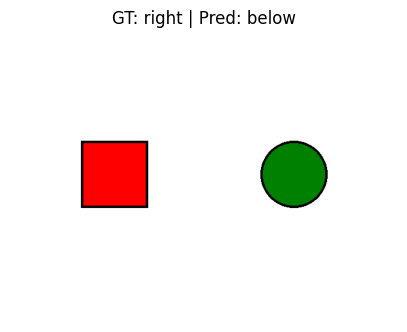

Question: Where is the green circle relative to the red square? Answer using only one lowercase word: left, right, above, or below.
Raw prediction: below


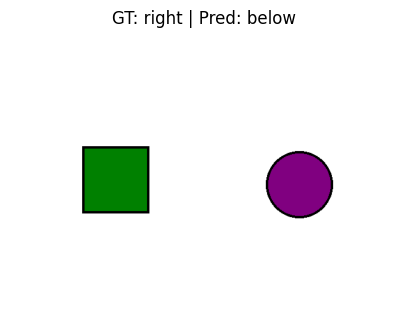

Question: Where is the purple circle relative to the green square? Answer using only one lowercase word: left, right, above, or below.
Raw prediction: below


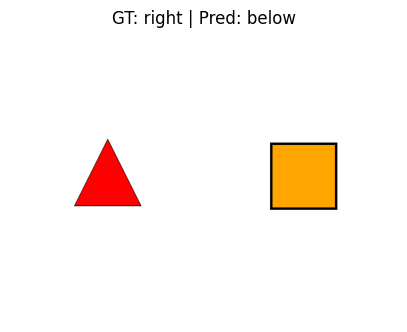

Question: Where is the orange square relative to the red triangle? Answer using only one lowercase word: left, right, above, or below.
Raw prediction: below


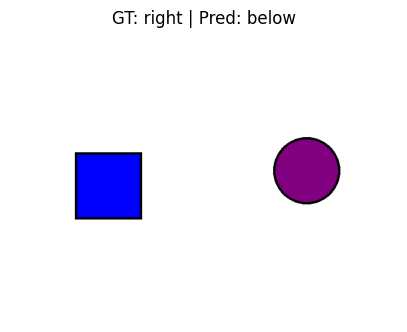

Question: Where is the purple circle relative to the blue square? Answer using only one lowercase word: left, right, above, or below.
Raw prediction: below


In [38]:
def show_failure_case(
    row: pd.Series,
) -> None:
    image = Image.open(row["image_paths"][0])

    plt.figure(figsize=(5, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f'GT: {row["ground_truth"]} | '
        f'Pred: {row["prediction"]}'
    )
    plt.show()

    print("Question:", row["question"])
    print("Raw prediction:", row["raw_prediction"])


for _, row in failure_cases.head(4).iterrows():
    show_failure_case(row)

## 28. Save datasets and results

In [39]:
with open(
    RESULTS_DIR / "direct_dataset.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        direct_dataset,
        file,
        indent=2,
    )

with open(
    RESULTS_DIR / "distractor_dataset.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        distractor_dataset,
        file,
        indent=2,
    )

direct_results.to_csv(
    RESULTS_DIR / "direct_results.csv",
    index=False,
)

distractor_results.to_csv(
    RESULTS_DIR / "distractor_results.csv",
    index=False,
)

summary_df.to_csv(
    RESULTS_DIR / "summary.csv",
    index=False,
)

experiment_metadata = {
    "model": MODEL_ID,
    "seed": SEED,
    "torch_version": torch.__version__,
    "transformers_version": transformers.__version__,
    "huggingface_hub_version": huggingface_hub.__version__,
    "direct_accuracy": float(
        direct_results["correct"].mean()
    ),
    "distractor_accuracy": float(
        distractor_results["correct"].mean()
    ),
    "multi_image_answer": multi_image_answer,
    "localization_raw": localization_raw,
    "localization_prediction": localization_prediction,
    "localization_ground_truth": target_bbox_normalized,
}

with open(
    RESULTS_DIR / "experiment_metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        experiment_metadata,
        file,
        indent=2,
    )

print("Saved files:")

for path in sorted(RESULTS_DIR.iterdir()):
    print("-", path)

Saved files:
- spatial_vlm_project/results/direct_dataset.json
- spatial_vlm_project/results/direct_results.csv
- spatial_vlm_project/results/distractor_dataset.json
- spatial_vlm_project/results/distractor_results.csv
- spatial_vlm_project/results/experiment_metadata.json
- spatial_vlm_project/results/summary.csv


# Optional extension — Qwen2.5-VL

The core project is complete above.

A second model should be added only after the SmolVLM2 benchmark runs successfully from top to bottom.

The same generated datasets and metrics can be reused. The only component that changes is the model adapter.

Recommended model:

`Qwen/Qwen2.5-VL-3B-Instruct`

This extension is particularly relevant for comparing:

- a compact VLM;
- a larger general-purpose VLM;
- language-based localization performance.

Do not run this section in the same session unless sufficient disk and GPU memory are available.

## Optional cleanup before loading another model

In [40]:
# Run only before loading a second model.
#
del model
del processor

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("GPU memory released.")

GPU memory released.


# Conclusions

This notebook demonstrates:

- robust local loading of an open-source VLM;
- multimodal chat formatting;
- image and text preprocessing;
- tensor inspection;
- deterministic generation;
- a reusable inference adapter;
- controlled procedural dataset generation;
- exact-match spatial-relation evaluation;
- distractor-based reasoning;
- multi-image reasoning;
- language-based localization;
- IoU evaluation;
- qualitative failure analysis.

A natural next step is to run the same benchmark with Qwen2.5-VL and compare task-level performance.